In [1]:
!pip install nltk
import nltk 
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/vydhyamvishnusai/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/vydhyamvishnusai/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/vydhyamvishnusai/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/vydhyamvishnusai/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [2]:
!pip install numpy 
!pip install pandas
!pip install scikit-learn


In [3]:
import numpy as np 
import pandas as pd 
import sklearn
from sklearn.datasets import fetch_20newsgroups 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer 
import re 
import nltk
from nltk.stem import WordNetLemmatizer 
from nltk.tokenize import word_tokenize 
from sklearn.naive_bayes import MultinomialNB 
from sklearn.model_selection import train_test_split


In [4]:
p_spam = 3000 / 10000
p_ham = 7000/ 10000 
word_probs_spam = {'get': 900/ 10000, 'free': 1200/ 10000, 'money': 1100/10000, 'now': 800/ 10000}
word_probs_ham = {'get': 150/ 10000, 'free': 70/ 10000, 'money': 60/10000, 'now': 100/ 10000} 
#calculate probability propotional to spam and ham 
p_sms_givem_spam = p_spam 
for word in ['get', 'free', 'money', 'now']:
    p_sms_givem_spam *= word_probs_spam[word]
p_sms_given_ham = p_ham 
for word in ['get', 'free', 'money', 'now']:
    p_sms_given_ham *= word_probs_ham[word]
print(f"Probability of SMS being spam:{ p_sms_givem_spam:.10f}")
print(f"Probability of SMS being ham:{ p_sms_given_ham:.10f}") 
print("Prediction:", "spam" if p_sms_givem_spam > p_sms_given_ham else "Ham")


Probability of SMS being spam:0.0000285120
Probability of SMS being ham:0.0000000044
Prediction: spam


# sample email dataset

In [5]:
data = {
    'text': [
        "Free money now!!!",
        "Hi Bob, how about a game tomorrow?",
        "Earn cash fast, click here!",
        "Are we meeting today for dinner?",
        "Limited offer, get free coupons!",
        "Don't forget the meeting at 10 am"
    ],
    'label': ['spam', 'ham', 'spam', 'ham', 'spam', 'ham']
} 
df = pd.DataFrame(data)
lemmatizer = WordNetLemmatizer()
def preprocess(text):
    tokens = word_tokenize(text.lower())
    lemmas = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(lemmas)
df['processed'] = df['text'].apply(preprocess)
print(df[['text', 'processed', 'label']])


                                 text                             processed  \
0                   Free money now!!!                  free money now ! ! !   
1  Hi Bob, how about a game tomorrow?  hi bob , how about a game tomorrow ?   
2         Earn cash fast, click here!         earn cash fast , click here !   
3    Are we meeting today for dinner?     are we meeting today for dinner ?   
4    Limited offer, get free coupons!     limited offer , get free coupon !   
5   Don't forget the meeting at 10 am    do n't forget the meeting at 10 am   

  label  
0  spam  
1   ham  
2  spam  
3   ham  
4  spam  
5   ham  


# TF-IDF

In [6]:
vectorizer = TfidfVectorizer(ngram_range= (1,2))
x = vectorizer.fit_transform(df['processed'])
features = vectorizer.get_feature_names_out() 
print(f"Number of features:{len(features)}")
print("Sample Features", features[:10])
print("\nTF-IDF Vectoirs (first email):") 
print(x.toarray()[0])

Number of features:56
Sample Features ['10' '10 am' 'about' 'about game' 'am' 'are' 'are we' 'at' 'at 10' 'bob']

TF-IDF Vectoirs (first email):
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.37935895 0.         0.46262479
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.46262479 0.46262479 0.46262479 0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]


In [7]:
!pip install matplotlib


Classification Report:
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00         1
        spam       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



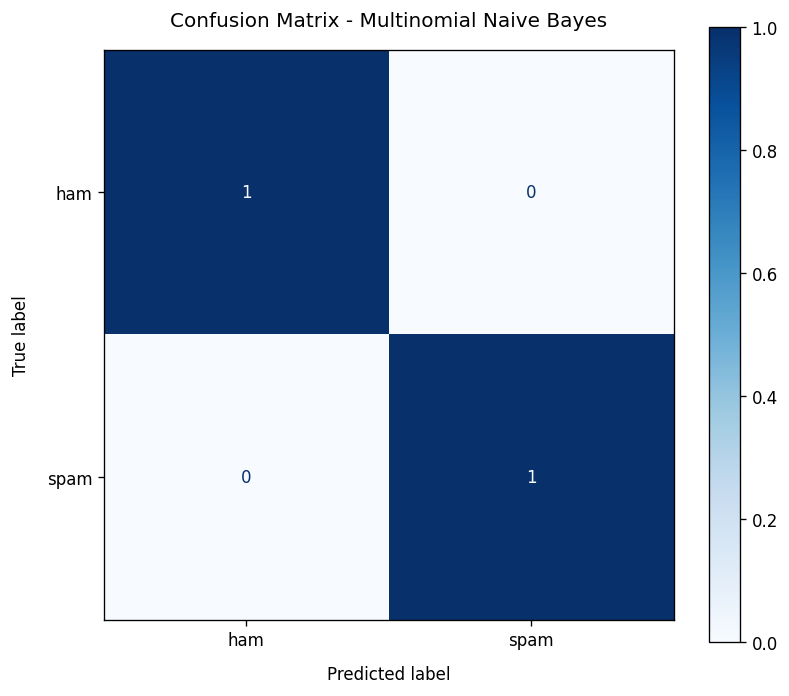

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

x_train, x_test, y_train, y_test = train_test_split(
    x,
    df['label'],
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

model = MultinomialNB()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
fig, ax = plt.subplots(figsize=(7, 6), dpi=120)
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)
display.plot(
    ax=ax,
    cmap='Blues',
    values_format='d',
    colorbar=True
)
ax.set_title("Confusion Matrix - Multinomial Naive Bayes", pad=14)
ax.set_xlabel("Predicted label", labelpad=10)
ax.set_ylabel("True label", labelpad=10)
ax.set_aspect('equal')
fig.tight_layout()
plt.show()

In [9]:
feature_log_probs = model.feature_log_prob_
print(feature_log_probs) 

[[-4.13722317 -4.13722317 -3.87369701 -3.87369701 -4.13722317 -3.87017479
  -3.87017479 -4.13722317 -4.13722317 -3.87369701 -3.87369701 -4.13722317
  -4.13722317 -4.13722317 -4.13722317 -4.13722317 -3.87017479 -4.13722317
  -4.13722317 -4.13722317 -4.13722317 -4.13722317 -4.13722317 -3.87017479
  -3.87017479 -4.13722317 -4.13722317 -4.13722317 -4.13722317 -4.13722317
  -3.87369701 -3.87369701 -4.13722317 -4.13722317 -4.13722317 -3.87369701
  -3.87369701 -3.87369701 -3.87369701 -4.13722317 -4.13722317 -3.91327246
  -4.13722317 -3.87017479 -4.13722317 -4.13722317 -4.13722317 -4.13722317
  -4.13722317 -4.13722317 -4.13722317 -3.87017479 -3.87017479 -3.87369701
  -3.87017479 -3.87017479]
 [-4.12705398 -4.12705398 -4.12705398 -4.12705398 -4.12705398 -4.12705398
  -4.12705398 -4.12705398 -4.12705398 -4.12705398 -4.12705398 -3.83937191
  -3.83937191 -3.83937191 -3.83937191 -3.83470506 -4.12705398 -4.12705398
  -4.12705398 -3.83937191 -3.83937191 -3.83937191 -3.83937191 -4.12705398
  -4.127053

In [10]:
#download and load sms spam collection dataset in colab

# Step 1: Download and unzip
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
!unzip smsspamcollection.zip

df = pd.read_csv('SMSSpamCollection', sep='\t', header=None, names=['label', 'text'])

--2026-09-16 19:28:49--  https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘smsspamcollection.zip’

smsspamcollection.z     [    <=>             ] 198.65K   228KB/s    in 0.9s    

2026-09-16 19:28:51 (228 KB/s) - ‘smsspamcollection.zip’ saved [203415]

Archive:  smsspamcollection.zip
  inflating: SMSSpamCollection       
  inflating: readme                  


In [11]:
print(df.shape)

(5572, 2)


In [13]:
df.groupby('label').size()

label
ham     4825
spam     747
dtype: int64

In [14]:
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
from sklearn.feature_extraction.text import CountVectorizer 
from sklearn.metrics import confusion_matrix, classification_report 
x_train_np, x_test_np, y_train_np, y_test_np = train_test_split(df['text'],df['label'], test_size = 0.2, 
                                                                random_state = 42, stratify = df['label'])
count_vec = CountVectorizer(stop_words = 'english', max_features = 2000)
x_train_vec_np = count_vec.fit_transform(x_train_np)
x_test_vec_np = count_vec.transform(x_test_np) 

model_np = MultinomialNB()
model_np.fit(x_train_vec_np, y_train_np)
y_pred_np = model_np.predict(x_test_vec_np) 
print(confusion_matrix(y_test_np, y_pred_np))
print("Accuracy:", (y_test_np == y_pred_np).mean())
print("Classification report:", classification_report(y_test_np, y_pred_np))


[[957   9]
 [ 11 138]]
Accuracy: 0.9820627802690582
Classification report:               precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.94      0.93      0.93       149

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115

